In [1]:
pip install beautifulsoup4

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
from bs4 import BeautifulSoup
import requests

In [3]:
import pandas as pd

In [4]:
pip install selenium

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
req = requests.get("https://www.diadora.com/it/it/")
soup = BeautifulSoup(req.text, "html.parser")

In [6]:
print(req.status_code)  
print(soup.prettify()[:500])  

200
<!DOCTYPE html>
<html lang="it">
 <head>
  <!--[if gt IE 9]><!-->
  <script defer="" src="https://player.vimeo.com/api/player.js">
  </script>
  <script>
   //common/scripts.isml
  </script>
  <script defer="" src="/on/demandware.static/Sites-IT-Site/-/it_IT/v1779482195766/js/main.js" type="text/javascript">
  </script>
  <script defer="" src="/on/demandware.static/Sites-IT-Site/-/it_IT/v1779482195766/js/select2.js">
  </script>
  <script defer="" src="/on/demandware.static/Sites-IT-Site/-/it_IT


In [7]:
print(type(req.text))
print(type(soup))

<class 'str'>
<class 'bs4.BeautifulSoup'>


In [8]:
prezzo=soup.find_all("div",class_="priceCustom")
print(prezzo)

[<div class="priceCustom">
<div class="product__price">
<div class="itemProduct__price d-flex align-items-center">
<div class="d-flex align-items-end">
<span class="price__basic">
                € 230,00

</span>
</div>
</div>
</div>
</div>, <div class="priceCustom">
<div class="product__price">
<div class="itemProduct__price d-flex align-items-center">
<div class="d-flex align-items-end">
<span class="price__basic">
                € 200,00

</span>
</div>
</div>
</div>
</div>, <div class="priceCustom">
<div class="product__price">
<div class="itemProduct__price d-flex align-items-center">
<div class="d-flex align-items-end">
<span class="price__basic">
                € 170,00

</span>
</div>
</div>
</div>
</div>, <div class="priceCustom">
<div class="product__price">
<div class="itemProduct__price d-flex align-items-center">
<div class="d-flex align-items-end">
<span class="price__basic">
                € 140,00

</span>
</div>
</div>
</div>
</div>, <div class="priceCustom">
<div 

In [9]:
title= soup.find_all("span",class_="product_title_name")
print(title)

[<span class="product_title_name"> PRESTIGE AGED ITALIA </span>, <span class="product_title_name"> PRESTIGE HIGH METAL USED </span>, <span class="product_title_name"> MYTHOS STAR LEA </span>, <span class="product_title_name"> GOLD INDOOR METALLIC </span>, <span class="product_title_name"> PRESTIGE METAL USED </span>, <span class="product_title_name"> RALLY PUNCHED </span>, <span class="product_title_name"> GAME L HIGH WAXED </span>, <span class="product_title_name"> TRAINER SUEDE </span>, <span class="product_title_name"> CAMARO M2 SMOOTH </span>, <span class="product_title_name"> B.ELITE '84 ITALIA </span>, <span class="product_title_name"> MYTHOS BLUSHIELD VIGORE V </span>, <span class="product_title_name"> B. ELITE STAR </span>, <span class="product_title_name"> ATOMO STAR </span>, <span class="product_title_name"> CELLULA  2 W </span>, <span class="product_title_name"> MYTHOS BLUSHIELD VIGORE V W </span>, <span class="product_title_name"> BLUSHIELD TORNEO 3 CLAY </span>, <span clas

In [10]:
titles=[]
for title in soup.find_all("span",class_="product_title_name"):
    titles.append(title.text.strip())
print(titles)

['PRESTIGE AGED ITALIA', 'PRESTIGE HIGH METAL USED', 'MYTHOS STAR LEA', 'GOLD INDOOR METALLIC', 'PRESTIGE METAL USED', 'RALLY PUNCHED', 'GAME L HIGH WAXED', 'TRAINER SUEDE', 'CAMARO M2 SMOOTH', "B.ELITE '84 ITALIA", 'MYTHOS BLUSHIELD VIGORE V', 'B. ELITE STAR', 'ATOMO STAR', 'CELLULA  2 W', 'MYTHOS BLUSHIELD VIGORE V W', 'BLUSHIELD TORNEO 3 CLAY', 'CELLULA 2', 'BLUSHIELD TORNEO 3 W CLAY', 'NUCLEO 2 W', 'NUCLEO 2']


In [11]:
prices=[]
for prezzo in soup.find_all("div",class_="priceCustom"):
    prices.append(prezzo.text.strip())
print(prices)

['€ 230,00', '€ 200,00', '€ 170,00', '€ 140,00', '€ 190,00', '€ 120,00', '€ 105,00', '€ 130,00', '€ 85,00', '€ 220,00', '€ 170,00', '€ 190,00', '€ 190,00', '€ 170,00', '€ 170,00', '€ 155,00', '€ 170,00', '€ 155,00', '€ 155,00', '€ 155,00']


In [12]:
all_titles = []
all_prices = []

for page in range(1, 10):  # prime 10 pagine
    url = f"https://www.diadora.com/it/it/search?q=scarpe&start={page*24}"
    req = requests.get(url)
    soup = BeautifulSoup(req.text, "html.parser")
    
    for title in soup.find_all("span", class_="product_title_name"):
        all_titles.append(title.text.strip())
    
    for price in soup.find_all("div", class_="priceCustom"):
        all_prices.append(price.text.strip())

print(len(all_titles))

216


In [13]:
import pandas as pd

df = pd.DataFrame({
    "nome": all_titles,
    "prezzo": all_prices
})

print(df.head())
print(df.shape)

                  nome    prezzo
0            CAMARO M2   € 85,00
1    GAME L HIGH WAXED  € 105,00
2  EQUIPE DIRTY SW EVO  € 180,00
3    B.560 FORO ITALIA  € 260,00
4       MI BASKET USED  € 200,00
(216, 2)


In [14]:
links = {
    # uomo
    "uomo_heritage": "https://www.diadora.com/it/it/uomo-scarpe-heritage/",
    "uomo_sportswear": "https://www.diadora.com/it/it/uomo-scarpe-sportswear/",
    "uomo_running": "https://www.diadora.com/it/it/uomo-scarpe-running/",
    "uomo_tennis": "https://www.diadora.com/it/it/uomo-scarpe-tennis/",
    "uomo_calcio": "https://www.diadora.com/it/it/uomo-scarpe-calcio/",
    "uomo_calcetto": "https://www.diadora.com/it/it/uomo-scarpe-calcetto/",
    "uomo_padel": "https://www.diadora.com/it/it/uomo-scarpe-padel/",
    # donna
    "donna_heritage": "https://www.diadora.com/it/it/donna-scarpe-heritage/",
    "donna_sportswear": "https://www.diadora.com/it/it/donna-scarpe-sportswear/",
    "donna_running": "https://www.diadora.com/it/it/donna-scarpe-running/",
    "donna_tennis": "https://www.diadora.com/it/it/donna-scarpe-tennis/",
    "donna_calcio": "https://www.diadora.com/it/it/donna-scarpe-calcio/",
    "donna_padel": "https://www.diadora.com/it/it/donna-scarpe-padel/",
    # bambini
    "bambini_sportswear": "https://www.diadora.com/it/it/bambini-scarpe-sportswear/",
    "bambini_running": "https://www.diadora.com/it/it/bambini-scarpe-running/",
    "bambini_tennis": "https://www.diadora.com/it/it/bambini-scarpe-tennis/",
    "bambini_calcio": "https://www.diadora.com/it/it/bambini-scarpe-calcio/",
    "bambini_calcetto": "https://www.diadora.com/it/it/bambini-scarpe-calcetto/",
}

for tipologia, url in links.items():
    req = requests.get(url)
    print(tipologia, req.status_code)

uomo_heritage 200
uomo_sportswear 200
uomo_running 200
uomo_tennis 200
uomo_calcio 200
uomo_calcetto 200
uomo_padel 200
donna_heritage 200
donna_sportswear 200
donna_running 200
donna_tennis 200
donna_calcio 200
donna_padel 200
bambini_sportswear 200
bambini_running 200
bambini_tennis 200
bambini_calcio 200
bambini_calcetto 200


In [15]:
all_diadora = []

for tipologia, url in links.items():
    for page in range(0, 200, 24):
        req = requests.get(f"{url}?start={page}")
        soup = BeautifulSoup(req.text, "html.parser")
        
        prodotti = soup.find_all("div", class_="itemProduct product-tile productTileHover")
        
        if len(prodotti) == 0:
            break
        
        for prodotto in prodotti:
            nome = prodotto.find("span", class_="product_title_name").text.strip()
            prezzo = prodotto.find("span", class_="price__basic").text.strip()
            
            all_diadora.append({
                "nome": nome,
                "prezzo": prezzo,
                "tipologia": tipologia,
                "brand": "Diadora"
            })

df_diadora = pd.DataFrame(all_diadora)
df_diadora["prezzo"] = df_diadora["prezzo"].str.replace("€ ", "").str.replace(",", ".").astype(float)
df_diadora["categoria"] = df_diadora["tipologia"].str.extract(r'(uomo|donna|bambini)')
df_diadora["tipologia"] = df_diadora["tipologia"].str.replace("uomo_","").str.replace("donna_","").str.replace("bambini_","")

print(df_diadora.shape)
print(df_diadora["tipologia"].value_counts())

(1009, 5)
tipologia
sportswear    346
heritage      292
running       213
tennis         72
calcio         68
calcetto       12
padel           6
Name: count, dtype: int64


In [16]:
print(df_diadora[["categoria","tipologia"]].value_counts())

categoria  tipologia 
donna      heritage      167
           sportswear    130
uomo       heritage      125
           sportswear    123
           running       105
bambini    sportswear     93
donna      running        91
uomo       calcio         47
           tennis         41
donna      tennis         29
bambini    running        17
donna      calcio         16
uomo       calcetto       10
bambini    calcio          5
uomo       padel           4
donna      padel           2
bambini    tennis          2
           calcetto        2
Name: count, dtype: int64


In [17]:
analisi_diadora = df_diadora.groupby(["categoria","tipologia"])["prezzo"].agg(["mean","min","max","count"]).round(2)
print(analisi_diadora)

                        mean    min    max  count
categoria tipologia                              
bambini   calcetto     45.00   45.0   45.0      2
          calcio       46.00   45.0   50.0      5
          running      55.18   35.0   80.0     17
          sportswear   34.49   25.0   45.0     93
          tennis       45.00   45.0   45.0      2
donna     calcio      261.88  210.0  300.0     16
          heritage    205.39  180.0  260.0    167
          padel       112.50   70.0  155.0      2
          running     178.19   70.0  300.0     91
          sportswear  112.65   18.0  230.0    130
          tennis      150.86   70.0  190.0     29
uomo      calcetto     66.00   55.0  100.0     10
          calcio      159.89   55.0  300.0     47
          heritage    201.36  180.0  260.0    125
          padel       121.25   70.0  155.0      4
          running     170.00   70.0  290.0    105
          sportswear  110.98   18.0  220.0    123
          tennis      149.76   60.0  190.0     41


In [18]:
url_nero = "https://nerogiardini.it/it"
req = requests.get(url_nero)
print(req.status_code)
print(soup.prettify()[:500])

200
<!DOCTYPE html>
<html lang="it">
 <head>
  <!--[if gt IE 9]><!-->
  <script defer="" src="https://player.vimeo.com/api/player.js">
  </script>
  <script>
   //common/scripts.isml
  </script>
  <script defer="" src="/on/demandware.static/Sites-IT-Site/-/it_IT/v1779482195766/js/main.js" type="text/javascript">
  </script>
  <script defer="" src="/on/demandware.static/Sites-IT-Site/-/it_IT/v1779482195766/js/select2.js">
  </script>
  <script defer="" src="/on/demandware.static/Sites-IT-Site/-/it_IT


In [19]:
url_nero = "https://nerogiardini.it/it/collections/uomo-calzature/online"
req = requests.get(url_nero)
soup = BeautifulSoup(req.text, "html.parser")
print(req.status_code)

titles = []
for title in soup.find_all("h2", class_="product-title"):
    titles.append(title.text.strip())

print(titles[:5])
print(len(titles))

200
['Mocassini Uomo in Pelle', 'Derby Uomo in Vernice', 'Derby Uomo in Pelle', 'Stringate Uomo in Pelle', 'Mocassini Uomo in Camoscio']
16


In [20]:
url_nero = "https://nerogiardini.it/it/collections/uomo-calzature/online?page=2"
req = requests.get(url_nero)
soup = BeautifulSoup(req.text, "html.parser")

titles = []
for title in soup.find_all("h2", class_="product-title"):
    titles.append(title.text.strip())

print(len(titles))
print(titles[:5])

16
['Stringate Uomo in Pelle', 'Sneakers Uomo in Camoscio e Tela', 'Sneakers Uomo in Camoscio e Tela', 'Sneakers Uomo in Pelle e Camoscio', 'Sneakers Uomo in Camoscio']


In [21]:
all_nero = []

categorie_nero = {
    "uomo": "https://nerogiardini.it/it/collections/uomo-calzature/online",
    "donna": "https://nerogiardini.it/it/collections/donna-calzature/online",
    "teen_ragazza": "https://nerogiardini.it/it/collections/ragazza-teen-calzature/online",
    "teen_ragazzo": "https://nerogiardini.it/it/collections/teen-ragazzo-calzature/online",
    "junior_bambina": "https://nerogiardini.it/it/collections/junior-bambina-calzature/online",
    "junior_bambino": "https://nerogiardini.it/it/collections/junior-bambino-calzature/online"
}


for tipologia, url in categorie_nero.items():
    page = 1
    while True:
        req = requests.get(f"{url}?page={page}")
        soup = BeautifulSoup(req.text, "html.parser")
        
        titles = soup.find_all("h2", class_="product-title")
        
        if len(titles) == 0:
            break
        
        for title in titles:
            all_nero.append({
                "nome": title.text.strip(),
                "categoria": tipologia,
                "brand": "Nerogiardini"
            })
        
        page += 1

df_nero = pd.DataFrame(all_nero)
print(df_nero.shape)
print(df_nero["categoria"].value_counts())

(646, 3)
categoria
donna             437
uomo              105
teen_ragazza       41
junior_bambina     33
teen_ragazzo       15
junior_bambino     15
Name: count, dtype: int64


In [22]:
all_nero = []

for tipologia, url in categorie_nero.items():
    page = 1
    while True:
        req = requests.get(f"{url}?page={page}")
        soup = BeautifulSoup(req.text, "html.parser")
        
        titles = soup.find_all("h2", class_="product-title")
        prices = soup.find_all("span", class_="price")
        
        if len(titles) == 0:
            break
        
        for title, price in zip(titles, prices):
            all_nero.append({
                "nome": title.text.strip(),
                "prezzo": price.text.strip(),
                "categoria": tipologia,
                "brand": "Nerogiardini"
            })
        
        page += 1

df_nero = pd.DataFrame(all_nero)
print(df_nero.shape)
print(df_nero.head())

(121, 4)
                         nome   prezzo categoria         brand
0     Mocassini Uomo in Pelle  €139,50      uomo  Nerogiardini
1       Derby Uomo in Vernice  €149,50      uomo  Nerogiardini
2         Derby Uomo in Pelle  €149,50      uomo  Nerogiardini
3     Stringate Uomo in Pelle  €149,50      uomo  Nerogiardini
4  Mocassini Uomo in Camoscio  €149,50      uomo  Nerogiardini


In [23]:
# pulizia prezzo
df_nero["prezzo"] = df_nero["prezzo"].str.replace("€", "").str.replace(",", ".").astype(float)


def categorizza_nero(nome):
    nome = nome.lower()
    if "sneaker" in nome:
        return "Sneaker"
    elif "mocassini" in nome:
        return "Mocassini"
    elif "derby" in nome:
        return "Derby"
    elif "sandal" in nome:
        return "Sandali"
    elif "stival" in nome:
        return "Stivali"
    elif "stringate" in nome:
        return "Stringate"
    elif "anfibio" in nome or "anfibi" in nome:
        return "Anfibi"
    elif "ballerine" in nome:
        return "Ballerine"
    else:
        return "Altro"

df_nero["tipologia"] = df_nero["nome"].apply(categorizza_nero)

print(df_nero["tipologia"].value_counts())

tipologia
Sneaker      55
Mocassini    18
Stivali      13
Altro        13
Stringate    10
Derby         7
Sandali       3
Anfibi        2
Name: count, dtype: int64


In [24]:
# tolto filtro con Altro
df_nero = df_nero[df_nero["tipologia"] != "Altro"]

# analisi finale
analisi_nero = df_nero.groupby("tipologia")["prezzo"].agg(["mean","min","max","count"]).round(2)
print(analisi_nero)

             mean    min    max  count
tipologia                             
Anfibi     179.50  179.5  179.5      2
Derby      150.93  139.5  159.5      7
Mocassini  151.17  139.5  159.5     18
Sandali    172.83  159.5  179.5      3
Sneaker    155.28  139.5  349.0     55
Stivali    171.27  155.0  189.5     13
Stringate  150.60  139.5  159.5     10


In [25]:
print(df_nero.columns.tolist())
print(df_nero["categoria"].value_counts())

['nome', 'prezzo', 'categoria', 'brand', 'tipologia']
categoria
uomo     103
donna      5
Name: count, dtype: int64


In [26]:
analisi_nero = df_nero.groupby(["categoria","tipologia"])["prezzo"].agg(["mean","min","max","count"]).round(2)
print(analisi_nero)

                       mean    min    max  count
categoria tipologia                             
donna     Sandali    172.83  159.5  179.5      3
          Sneaker    139.50  139.5  139.5      2
uomo      Anfibi     179.50  179.5  179.5      2
          Derby      150.93  139.5  159.5      7
          Mocassini  151.17  139.5  159.5     18
          Sneaker    155.88  139.5  349.0     53
          Stivali    171.27  155.0  189.5     13
          Stringate  150.60  139.5  159.5     10


In [27]:
url_superga = "https://www.superga.com/it/"
req = requests.get(url_superga)
print(req.status_code)
print(soup.prettify()[:500])

200
<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width, initial-scale=1.0" name="viewport"/>
  <title>
   Verifying your connection...
  </title>
  <style type="text/css">
   *{box-sizing:border-box;margin:0;padding:0}html{font-family:"Helvetica Neue",Helvetica,Arial,sans-serif;background:#FFF;font-size:62.5%;color:#303030;min-height:100%}body{padding:0;margin:0;line-height:2.7rem}a{color:#303030;border-bottom:1px solid #303030;text-decoration:none


In [28]:
url_superga = "https://www.superga.com/it/collections/scarpe-di-tela-donna"
req = requests.get(url_superga)
soup = BeautifulSoup(req.text, "html.parser")
print(req.status_code)

titles = soup.find_all("h3", class_="grid-product__title grid-product__title--heading")
print(len(titles))
print(titles[:3])

200
36
[<h3 class="grid-product__title grid-product__title--heading">
<a class="grid-product__link" data-collection-title="Scarpe Donna " href=" /it/products/le-superga-unisex-2750-linen-beige-natural-off-white-s6138iw-a0j ">
2750 LINEN<span class="colorname-title">BEIGE NATURAL-OFF WHITE</span>
</a>
</h3>, <h3 class="grid-product__title grid-product__title--heading">
<a class="grid-product__link" data-collection-title="Scarpe Donna " href=" /it/products/le-superga-woman-2750-raffia-lilla-multicolor-herringbone-s5133sw-a0i ">
2750 RAFFIA<span class="colorname-title">LILLA MULTICOLOR HERRINGBONE</span>
</a>
</h3>, <h3 class="grid-product__title grid-product__title--heading">
<a class="grid-product__link" data-collection-title="Scarpe Donna " href=" /it/products/le-superga-unisex-1925-total-beige-raw-s2168rw-a9w ">
1925<span class="colorname-title">TOTAL BEIGE RAW</span>
</a>
</h3>]


In [29]:
categorie_superga_uomo = {
    "sneaker_uomo": "https://www.superga.com/it/collections/mens-sneakers",
    "espadrillas_uomo": "https://www.superga.com/it/collections/mens-espadrilles",
    "sandali_uomo": "https://www.superga.com/it/collections/mens-sandals",
    "stivali_uomo": "https://www.superga.com/it/collections/mens-boots"
}

for tipologia, url in categorie_superga_uomo.items():
    req = requests.get(url)
    print(tipologia, req.status_code)

sneaker_uomo 200
espadrillas_uomo 200
sandali_uomo 200
stivali_uomo 200


In [30]:
categorie_superga = {
    "sneaker_donna": "https://www.superga.com/it/collections/womens-sneakers",
    "platform_donna": "https://www.superga.com/it/collections/womens-platform",
    "sandali_donna": "https://www.superga.com/it/collections/women-s-sandals",
    "ballerina_donna": "https://www.superga.com/it/collections/womens-ballerina-shoes",
    "espadrillas_donna": "https://www.superga.com/it/collections/women-s-espadrilles",
    "mary_jane_donna": "https://www.superga.com/it/collections/mary-jane",
    "stivali_donna": "https://www.superga.com/it/collections/womens-boots"
}

for tipologia, url in categorie_superga.items():
    req = requests.get(url)
    print(tipologia, req.status_code)

sneaker_donna 200
platform_donna 200
sandali_donna 200
ballerina_donna 200
espadrillas_donna 200
mary_jane_donna 200
stivali_donna 200


In [31]:
categorie_superga_bambini = {
    "sneaker_bambini": "https://www.superga.com/it/collections/kids-sneakers",
    "senza_lacci_bambini": "https://www.superga.com/it/collections/scarpe-senza-lacci-per-bambini",
    "ballerina_bambini": "https://www.superga.com/it/collections/ballerine-per-bambina",
    "sandali_bambini": "https://www.superga.com/it/collections/kids-sandals",
    "espadrillas_bambini": "https://www.superga.com/it/collections/kids-espadrilles",
    "stivali_bambini": "https://www.superga.com/it/collections/kids-boots"
}

for tipologia, url in categorie_superga_bambini.items():
    req = requests.get(url)
    print(tipologia, req.status_code)

sneaker_bambini 200
senza_lacci_bambini 200
ballerina_bambini 200
sandali_bambini 200
espadrillas_bambini 200
stivali_bambini 200


In [33]:
all_superga = []

for tipologia, url in categorie_superga.items():
    req = requests.get(url)
    soup = BeautifulSoup(req.text, "html.parser")
    
    titles = soup.find_all("h3", class_="grid-product__title grid-product__title--heading")
    prices = soup.find_all("div", class_="grid-product__price")
    
    for title, price in zip(titles, prices):
        link = title.find("a")
        nome = link.contents[0].strip()
        prezzo = price.text.strip()
        
        if nome and prezzo:
            all_superga.append({
                "nome": nome,
                "prezzo": prezzo,
                "tipologia": tipologia,
                "brand": "Superga"
            })

df_superga = pd.DataFrame(all_superga)
df_superga["prezzo"] = df_superga["prezzo"].str.replace("€", "").str.replace(",", ".").astype(float)
df_superga["categoria"] = df_superga["tipologia"].str.extract(r'(donna|uomo|bambini)')
df_superga["tipologia"] = df_superga["tipologia"].str.replace("_donna","").str.replace("_uomo","").str.replace("_bambini","")

print(df_superga.shape)
print(df_superga[["categoria","tipologia"]].value_counts())

(109, 5)
categoria  tipologia  
donna      platform       32
           sneaker        32
           stivali        15
           espadrillas    12
           ballerina       7
           sandali         7
           mary_jane       4
Name: count, dtype: int64


In [34]:
analisi_superga = df_superga.groupby(["categoria","tipologia"])["prezzo"].agg(["mean","min","max","count"]).round(2)
print(analisi_superga)

                        mean   min    max  count
categoria tipologia                             
donna     ballerina    85.71  70.0  120.0      7
          espadrillas  60.42  55.0   70.0     12
          mary_jane    77.00  75.0   79.0      4
          platform     81.72  70.0  100.0     32
          sandali      85.71  80.0   90.0      7
          sneaker      90.12  65.0  150.0     32
          stivali      82.33  65.0  100.0     15


In [35]:
df_totale = pd.concat([df_diadora, df_nero, df_superga])

# confronto finale per brand e tipologia
analisi_finale = df_totale.groupby(["brand","tipologia"])["prezzo"].agg(["mean","min","max","count"]).round(2)
print(analisi_finale)

                            mean    min    max  count
brand        tipologia                               
Diadora      calcetto      62.50   45.0  100.0     12
             calcio       175.51   45.0  300.0     68
             heritage     203.66  180.0  260.0    292
             padel        118.33   70.0  155.0      6
             running      164.33   35.0  300.0    213
             sportswear    91.05   18.0  230.0    346
             tennis       147.29   45.0  190.0     72
Nerogiardini Anfibi       179.50  179.5  179.5      2
             Derby        150.93  139.5  159.5      7
             Mocassini    151.17  139.5  159.5     18
             Sandali      172.83  159.5  179.5      3
             Sneaker      155.28  139.5  349.0     55
             Stivali      171.27  155.0  189.5     13
             Stringate    150.60  139.5  159.5     10
Superga      ballerina     85.71   70.0  120.0      7
             espadrillas   60.42   55.0   70.0     12
             mary_jane     7

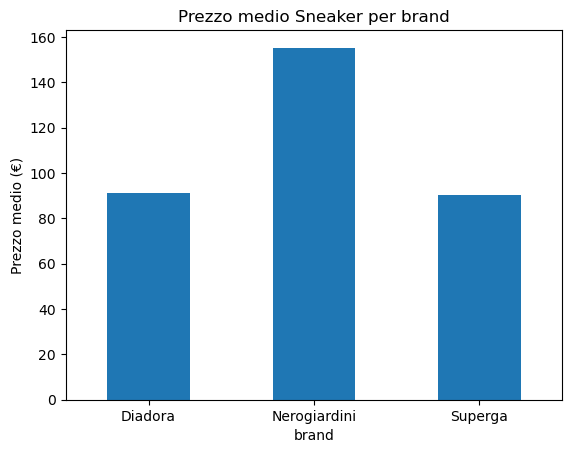

In [38]:
import matplotlib.pyplot as plt

sneaker = df_totale[df_totale["tipologia"].str.lower().isin(["sneaker", "sportswear"])]
sneaker_analisi = sneaker.groupby("brand")["prezzo"].mean().round(2)
sneaker_analisi.plot(kind="bar", title="Prezzo medio Sneaker per brand")
plt.ylabel("Prezzo medio (€)")
plt.xticks(rotation=0)
plt.show()

In [39]:
print("Diadora:", df_diadora["tipologia"].unique())
print("Nerogiardini:", df_nero["tipologia"].unique())
print("Superga:", df_superga["tipologia"].unique())

Diadora: ['heritage' 'sportswear' 'running' 'tennis' 'calcio' 'calcetto' 'padel']
Nerogiardini: ['Mocassini' 'Derby' 'Stringate' 'Sneaker' 'Stivali' 'Anfibi' 'Sandali']
Superga: ['sneaker' 'platform' 'sandali' 'ballerina' 'espadrillas' 'mary_jane'
 'stivali']


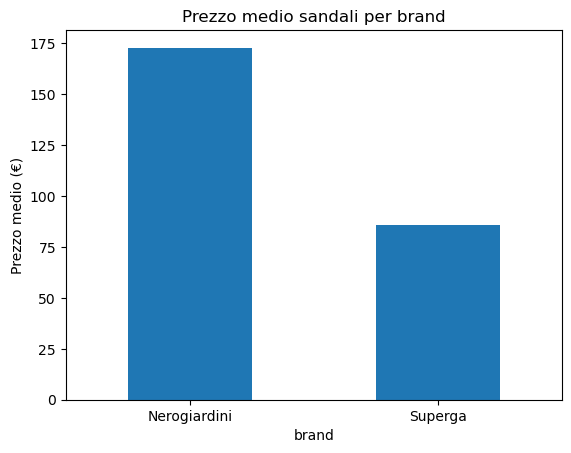

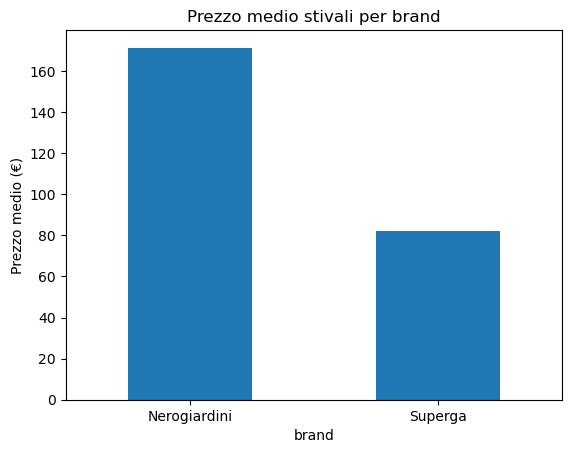

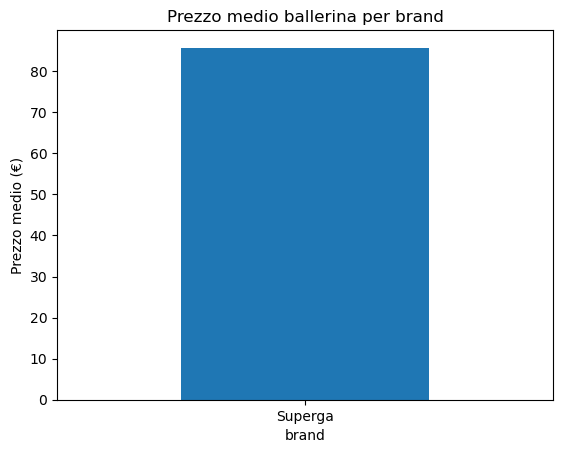

In [40]:
categorie_comuni = ["sandali", "stivali", "ballerina"]

for cat in categorie_comuni:
    dati = df_totale[df_totale["tipologia"].str.lower().isin([cat, cat+"i", cat+"e"])]
    analisi = dati.groupby("brand")["prezzo"].mean().round(2)
    analisi.plot(kind="bar", title=f"Prezzo medio {cat} per brand")
    plt.ylabel("Prezzo medio (€)")
    plt.xticks(rotation=0)
    plt.show()

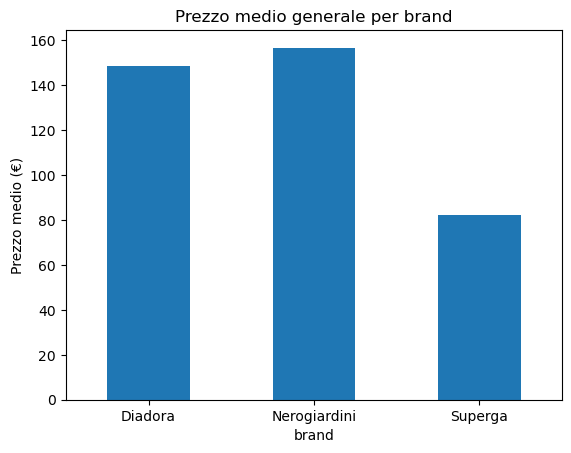

In [41]:
# prezzo medio generale per brand
df_totale.groupby("brand")["prezzo"].mean().round(2).plot(kind="bar", title="Prezzo medio generale per brand")
plt.ylabel("Prezzo medio (€)")
plt.xticks(rotation=0)
plt.show()

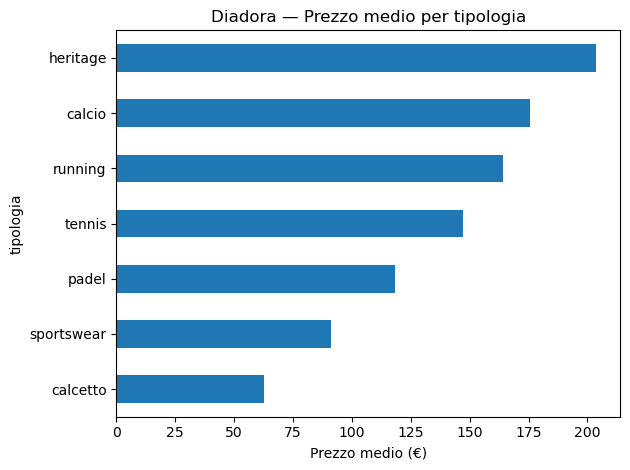

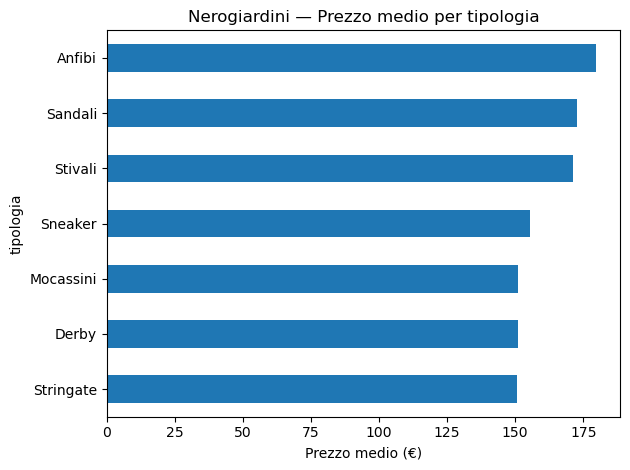

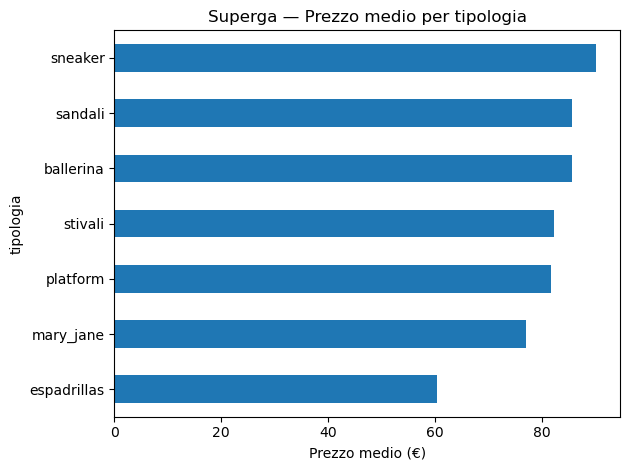

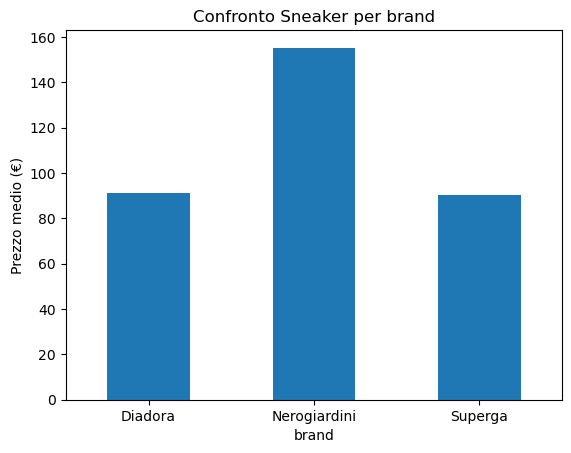

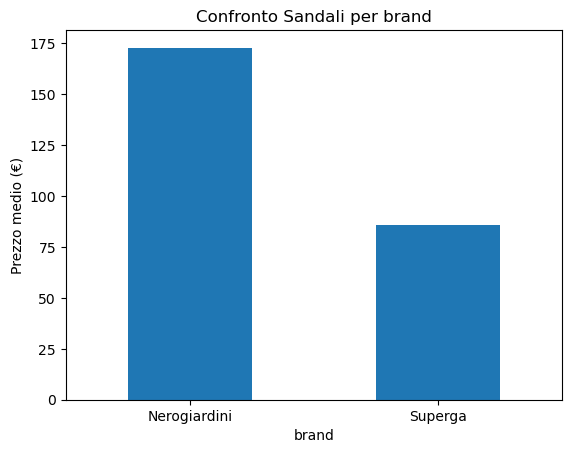

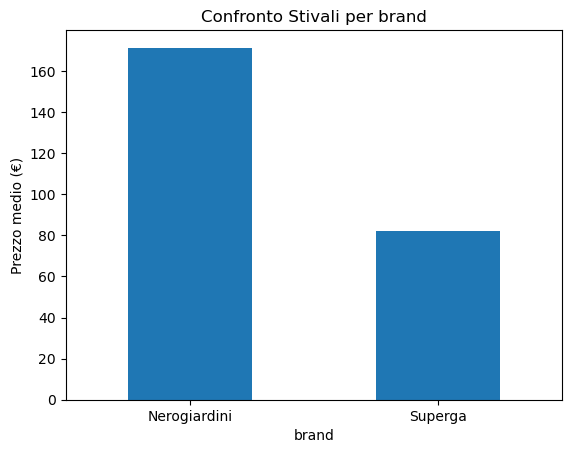

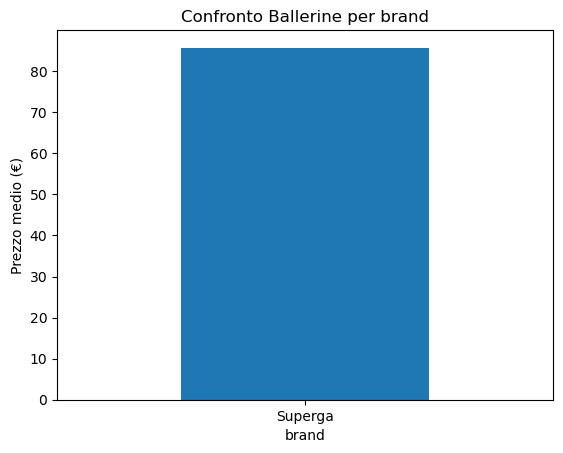

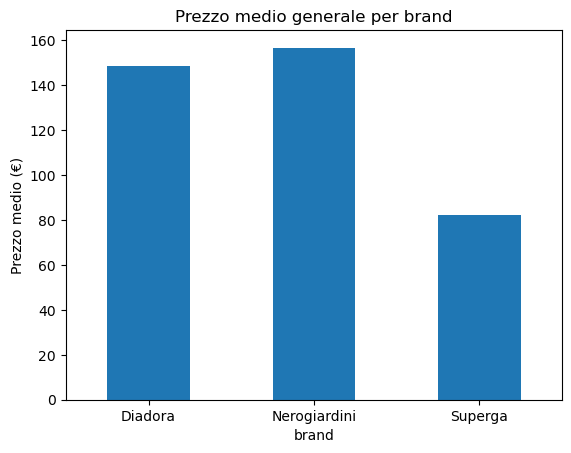

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# ── GRAFICO 1: DIADORA per tipologia ──────────────────────────────────────
analisi_diadora = df_diadora.groupby("tipologia")["prezzo"].mean().round(2).sort_values()
analisi_diadora.plot(kind="barh", title="Diadora — Prezzo medio per tipologia")
plt.xlabel("Prezzo medio (€)")
plt.tight_layout()
plt.show()

# ── GRAFICO 2: NEROGIARDINI per tipologia ─────────────────────────────────
analisi_nero = df_nero.groupby("tipologia")["prezzo"].mean().round(2).sort_values()
analisi_nero.plot(kind="barh", title="Nerogiardini — Prezzo medio per tipologia")
plt.xlabel("Prezzo medio (€)")
plt.tight_layout()
plt.show()

# ── GRAFICO 3: SUPERGA per tipologia ──────────────────────────────────────
analisi_superga = df_superga.groupby("tipologia")["prezzo"].mean().round(2).sort_values()
analisi_superga.plot(kind="barh", title="Superga — Prezzo medio per tipologia")
plt.xlabel("Prezzo medio (€)")
plt.tight_layout()
plt.show()

# ── GRAFICO 4: CONFRONTO SNEAKER ──────────────────────────────────────────
sneaker = df_totale[df_totale["tipologia"].str.lower().isin(["sneaker", "sportswear"])]
sneaker.groupby("brand")["prezzo"].mean().round(2).plot(kind="bar", title="Confronto Sneaker per brand")
plt.ylabel("Prezzo medio (€)")
plt.xticks(rotation=0)
plt.show()

# ── GRAFICO 5: CONFRONTO SANDALI ──────────────────────────────────────────
sandali = df_totale[df_totale["tipologia"].str.lower() == "sandali"]
sandali.groupby("brand")["prezzo"].mean().round(2).plot(kind="bar", title="Confronto Sandali per brand")
plt.ylabel("Prezzo medio (€)")
plt.xticks(rotation=0)
plt.show()

# ── GRAFICO 6: CONFRONTO STIVALI ──────────────────────────────────────────
stivali = df_totale[df_totale["tipologia"].str.lower() == "stivali"]
stivali.groupby("brand")["prezzo"].mean().round(2).plot(kind="bar", title="Confronto Stivali per brand")
plt.ylabel("Prezzo medio (€)")
plt.xticks(rotation=0)
plt.show()

# ── GRAFICO 7: CONFRONTO BALLERINE ────────────────────────────────────────
ballerine = df_totale[df_totale["tipologia"].str.lower().isin(["ballerine", "ballerina"])]
ballerine.groupby("brand")["prezzo"].mean().round(2).plot(kind="bar", title="Confronto Ballerine per brand")
plt.ylabel("Prezzo medio (€)")
plt.xticks(rotation=0)
plt.show()

# ── GRAFICO 8: CONFRONTO PREZZI GENERALE ─────────────────────────────────
df_totale.groupby("brand")["prezzo"].mean().round(2).plot(kind="bar", title="Prezzo medio generale per brand")
plt.ylabel("Prezzo medio (€)")
plt.xticks(rotation=0)
plt.show()